# Data & feature-space exploration (scratch)

Informal, step-by-step companion to `IMP01_missingness_landscape.ipynb` in this same folder.
Nothing here is "final" -- it's a place to poke at the data interactively before we decide what
goes into the next formal step (imputation algorithms).

In [1]:
# additional libraries

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import STL

In [2]:
from pathlib import Path
import sys

import pandas as pd

sys.path.insert(0, "../../src")

HOURLY = Path("../../data/Hourly")

df = pd.read_csv(HOURLY / "consolidated_hourly.csv", low_memory=False)
df["Datetime"] = pd.to_datetime(df["Datetime"], format="mixed")
df = df.set_index("Datetime")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Date range: {df.index.min()} -> {df.index.max()}")
print(f"Frequency check (should be 1h): {df.index.to_series().diff().mode()[0]}")

Shape: 70,153 rows x 449 cols
Date range: 2017-01-01 00:00:00 -> 2025-01-02 00:00:00
Frequency check (should be 1h): 0 days 01:00:00


In [3]:
df

,CO2_1_1_1 [Tower 2],H2O_1_1_1 [Tower 2],CH4_1_1_1 [Tower 2],TAU_1_1_1 [Tower 2],TAU_SSITC_TEST_1_1_1 [Tower 2],H_1_1_1 [Tower 2],H_SSITC_TEST_1_1_1 [Tower 2],LE_1_1_1 [Tower 2],LE_SSITC_TEST_1_1_1 [Tower 2],FC_1_1_1 [Tower 2],...,lamb_Catchment 12,lamb_Catchment 13,lamb_Catchment 14,lamb_Catchment 15,lamb_Red Shed,lamb_Green Shed,lamb_Blue Shed,lamb_Catchment 4 Prior to 2013/08/13,lamb_Brown Shed,lamb_Met
Datetime,,,,,,,,,,,,,,,,,,,,,
2017-01-01 00:00:00,373.002829,2.582062,NaN,0.069802,0.0,-17.133901,0.0,0.674787,0.0,1.873659,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 01:00:00,370.941935,2.625380,NaN,0.107350,0.0,-28.424088,0.0,1.347230,0.5,2.759884,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 02:00:00,371.457921,2.631636,NaN,0.093147,0.0,-18.809984,0.5,3.823392,0.5,1.259009,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 03:00:00,358.960009,2.112505,NaN,0.083412,0.0,-14.362518,1.0,-0.313933,0.5,2.382082,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2017-01-01 04:00:00,371.018281,2.141559,NaN,0.064629,0.5,-7.115667,1.0,-0.160060,1.0,3.013723,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 20:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 21:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-01-01 22:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
from features.tower_feature_space import get_tower_columns

TOWERS = [2, 4, 9]
tower_info = {n: get_tower_columns(df.columns, n) for n in TOWERS}

df_by_tower = {n: df[tower_info[n]["columns"]] for n in TOWERS}

for n in TOWERS:
    print(f"Tower {n}: {df_by_tower[n].shape[1]} columns, target = {tower_info[n]['target']}")

Tower 2: 69 columns, target = FCH4_1_1_1 [Tower 2]
Tower 4: 67 columns, target = FCH4_1_1_1 [Tower 4]
Tower 9: 67 columns, target = FCH4_1_1_1 [Tower 9]


In [5]:
import numpy as np

# .corr() defaults to pairwise-complete observations -- each column PAIR is correlated
# using only the rows where both happen to be non-NaN. No imputation needed.
corr_by_tower = {n: df_by_tower[n].corr() for n in TOWERS}


def top_pairs(corr, n_top=15):
    upper = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1))
    pairs = upper.stack()
    return pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(n_top)


for n in TOWERS:
    print(f"\n=== Tower {n}: top 15 |correlation| pairs (Pearson, pairwise-complete) ===")
    print(top_pairs(corr_by_tower[n]).to_string())


=== Tower 2: top 15 |correlation| pairs (Pearson, pairwise-complete) ===
USTAR_0_0_1 [Tower 2]                             W_SIGMA_0_0_1 [Tower 2]                       0.996688
PPFD_1_1_1 [Tower 2]                              SWIN_1_1_1 [Tower 2]                          0.994775
SWIN_1_1_1 [Tower 2]                              SWOUT_1_1_1 [Tower 2]                         0.984614
TS_1_1_1 [Tower 2]                                TS_3_1_1 [Tower 2]                            0.983417
RN_1_1_1 [Tower 2]                                SWIN_1_1_1 [Tower 2]                          0.981780
PPFD_1_1_1 [Tower 2]                              RN_1_1_1 [Tower 2]                            0.976360
                                                  SWOUT_1_1_1 [Tower 2]                         0.976311
FETCH_70_0_0_1 [Tower 2]                          FETCH_80_0_0_1 [Tower 2]                      0.975787
TAU_1_1_1 [Tower 2]                               WS_0_0_1 [Tower 2]                  

## Time series decomposition (replicating the statsmodels tutorial)

Replicating the decomposition approach from
[Time Series Modeling with statsmodels](https://www.geeksforgeeks.org/deep-learning/time-series-modeling-with-statsmodels/)
(GeeksforGeeks), which uses `statsmodels.tsa.seasonal.seasonal_decompose` on the AirPassengers
dataset with `model='multiplicative'` and plots the observed/trend/seasonal/residual components.

Adaptations for our data:
- **STL, not `seasonal_decompose`.** STL (Seasonal-Trend decomposition using LOESS) fits smooth
  trend/seasonal components iteratively and is inherently additive -- appropriate here since
  `FCH4` is signed (crosses zero, can go negative) and a multiplicative model wouldn't be valid.
- **`robust=True`.** Downweights outliers in the LOESS fits so the trend/seasonal components
  aren't distorted by extreme CH4 flux spike events (see the max vs. Q3 gap in `fch4.describe()`
  above -- e.g. Tower 9 max ~2775 vs. Q3 ~37).
- **Gap-filled series (`fch4_gapfilled.csv`).** STL requires no missing values; the raw EC flux
  has large gaps, so we use the continuous gap-filled FCH4 per tower (D-36) instead.

Run at two seasonal scales, all 3 towers each (per CLAUDE.md full-coverage default):
1. **Annual** — daily-mean resample, `period=365`.
2. **Diurnal** — native hourly resolution, `period=24` (plotted over a 2-week window for
   readability; decomposition itself uses the full series).

In [6]:
import matplotlib.pyplot as plt

fch4 = pd.read_csv(HOURLY / "fch4_gapfilled.csv", parse_dates=["Datetime"]).set_index("Datetime")
fch4_cols = {n: f"FCH4_gapfilled [Tower {n}]" for n in TOWERS}
fch4[list(fch4_cols.values())].describe()

,FCH4_gapfilled [Tower 2],FCH4_gapfilled [Tower 4],FCH4_gapfilled [Tower 9]
count,70153.00000,70153.000000,70153.000000
mean,19.39590,29.957504,36.656075
std,57.51582,89.051636,94.162107
min,-472.11470,-482.666000,-408.091000
25%,4.00820,3.611200,6.140900
50%,10.10060,11.494900,14.584400
75%,19.39320,30.107300,36.745600
max,2825.06670,2866.667500,2775.281000


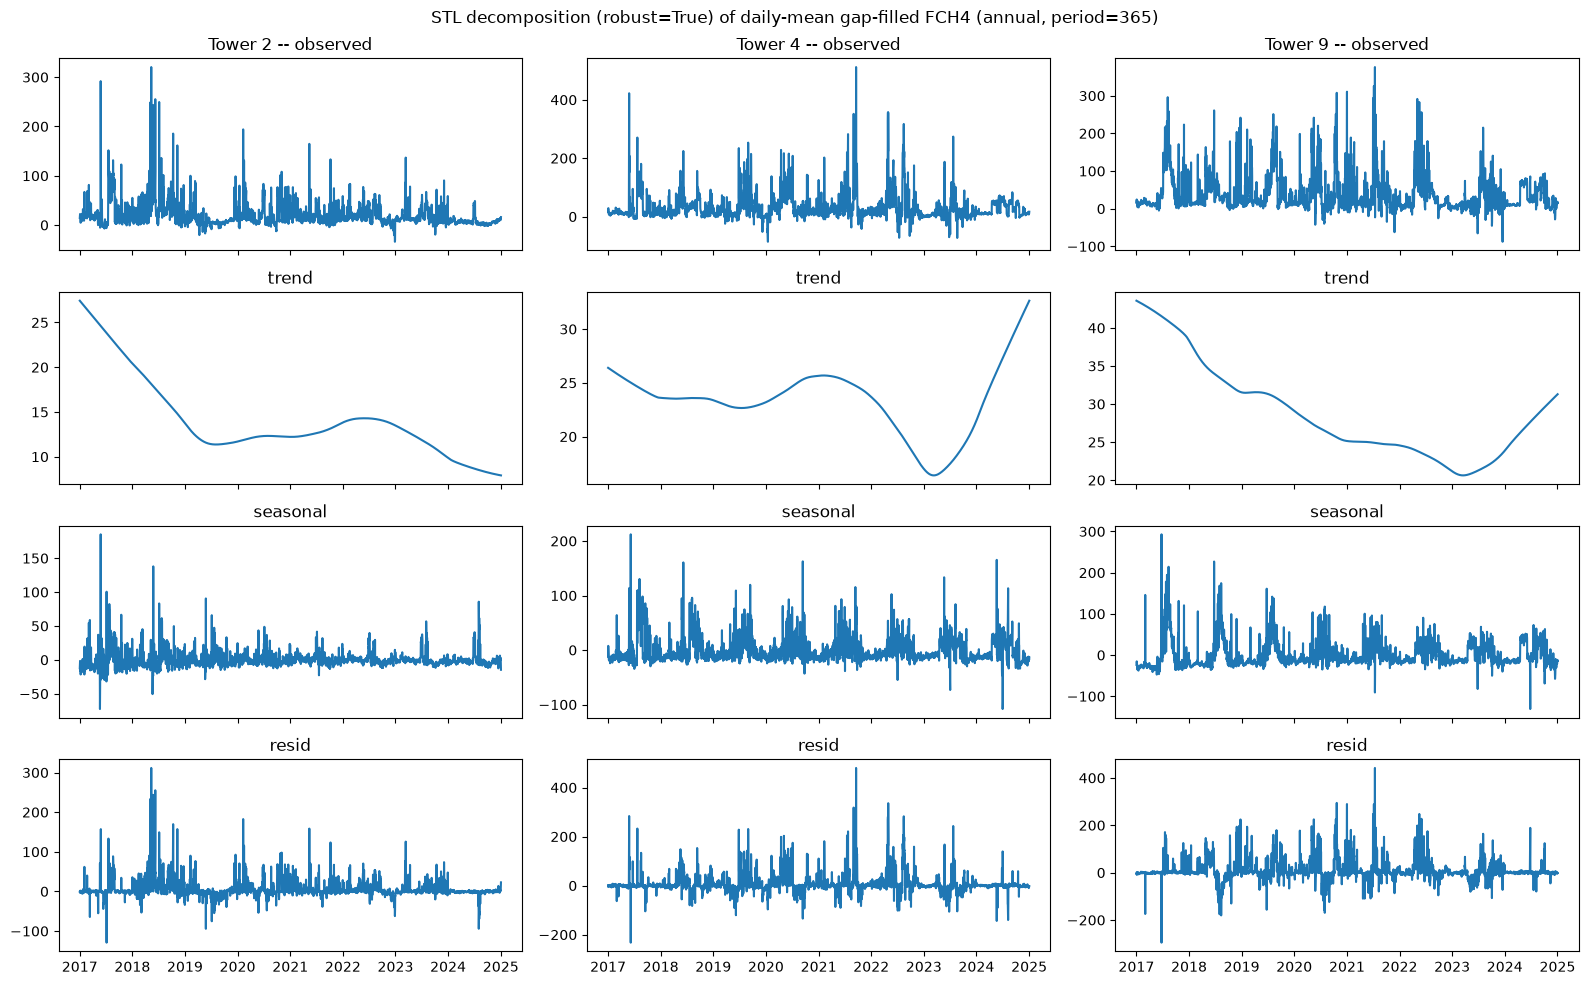

In [7]:
# Annual decomposition -- daily-mean resample, period=365, STL robust=True
decomp_annual = {
    n: STL(fch4[col].resample("1D").mean(), period=365, robust=True).fit()
    for n, col in fch4_cols.items()
}

fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex="col")
component_names = ["observed", "trend", "seasonal", "resid"]
for i, n in enumerate(TOWERS):
    d = decomp_annual[n]
    for row, comp in enumerate(component_names):
        axes[row, i].plot(getattr(d, comp))
        axes[row, i].set_title(f"Tower {n} -- {comp}" if row == 0 else comp)
fig.suptitle("STL decomposition (robust=True) of daily-mean gap-filled FCH4 (annual, period=365)")
fig.tight_layout()
plt.show()

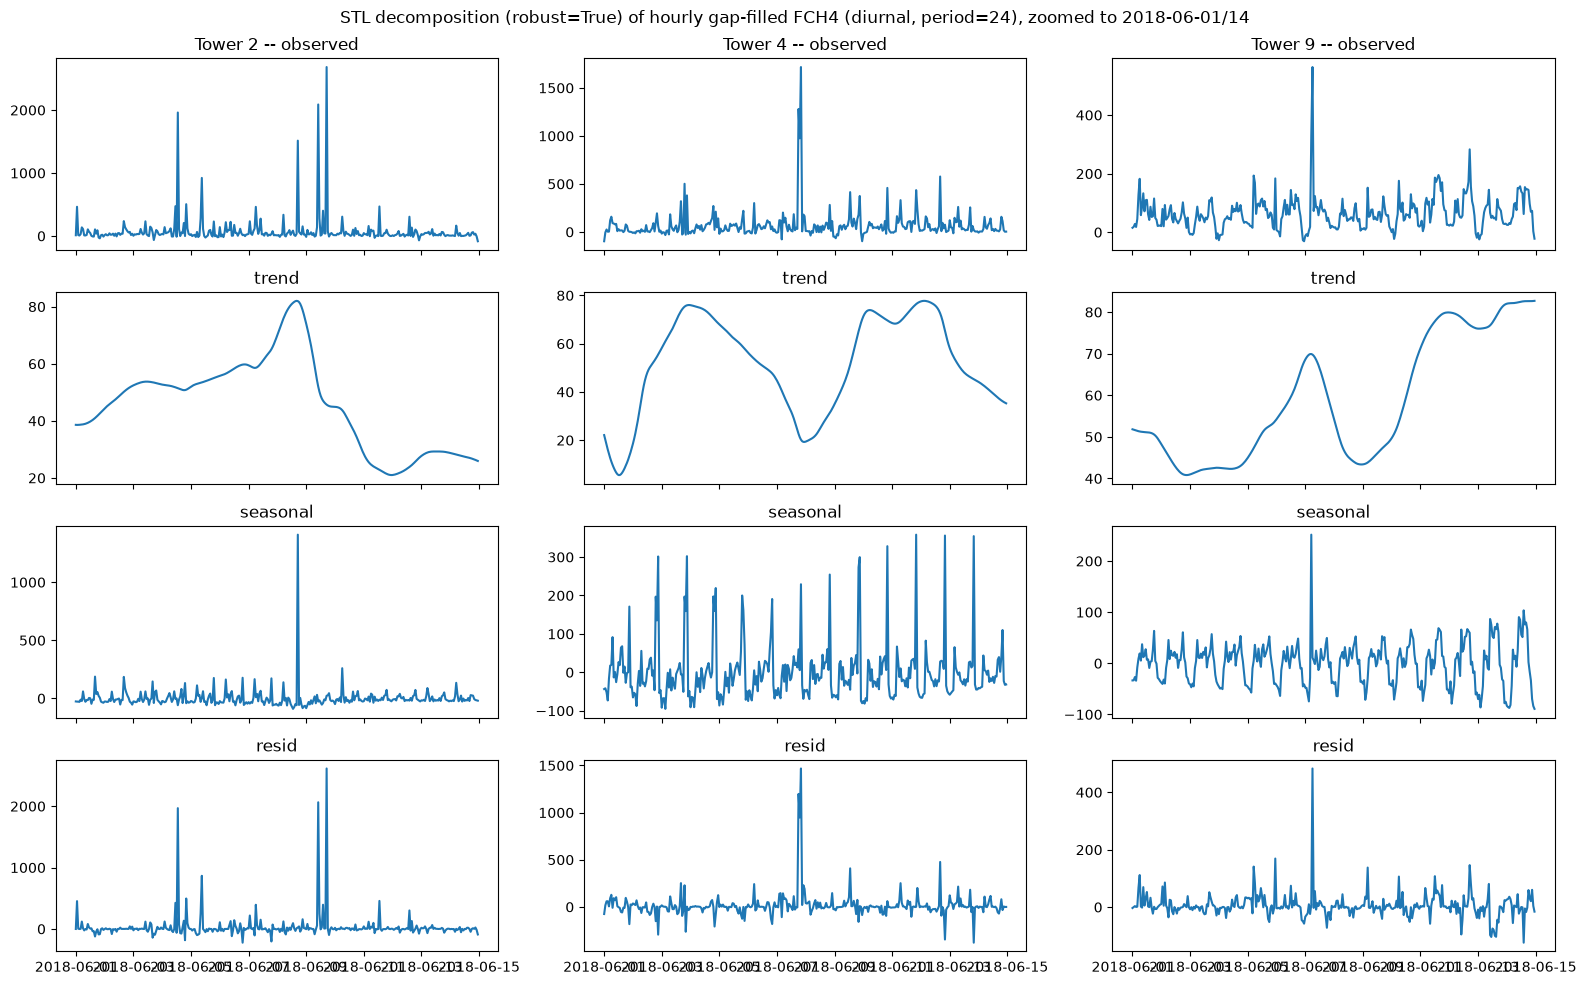

In [8]:
# Diurnal decomposition -- native hourly resolution, period=24, STL robust=True
# (decomposed on the full series; plotted over a 2-week window for readability)
decomp_diurnal = {n: STL(fch4[col], period=24, robust=True).fit() for n, col in fch4_cols.items()}

window = slice("2018-06-01", "2018-06-14")
fig, axes = plt.subplots(4, 3, figsize=(16, 10), sharex="col")
for i, n in enumerate(TOWERS):
    d = decomp_diurnal[n]
    for row, comp in enumerate(component_names):
        axes[row, i].plot(getattr(d, comp)[window])
        axes[row, i].set_title(f"Tower {n} -- {comp}" if row == 0 else comp)
fig.suptitle("STL decomposition (robust=True) of hourly gap-filled FCH4 (diurnal, period=24), zoomed to 2018-06-01/14")
fig.tight_layout()
plt.show()